In [1]:
from pathlib import Path
import numpy as np
import numpy.typing as npt
from skimage.feature import hessian_matrix, hessian_matrix_eigvals
import matplotlib.pyplot as plt

vmin = -3
vmax = 4

In [2]:
def apply_hessian_filter(image: npt.NDArray[np.float64], hessian_component: str, sigma: int = 1) -> npt.NDArray[np.float64]:
    """Apply a Hessian filter to the image"""
    hessian_matrix_image = hessian_matrix(image, sigma=sigma, order="rc", use_gaussian_derivatives=False)
    hessian_maximas, hessian_minimas = hessian_matrix_eigvals(hessian_matrix_image)
    if hessian_component == "high":
        return hessian_minimas
    elif hessian_component == "low":
        return hessian_maximas
    else:
        raise ValueError(f"Invalid hessian_component value: {hessian_component}. Must be 'high' or 'low'.")


image min max: 0.0, 1.0


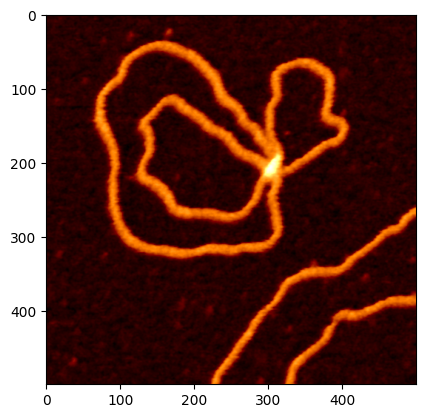

hessian_high_1s min max: -0.06651553536439427, 0.019752873116713893


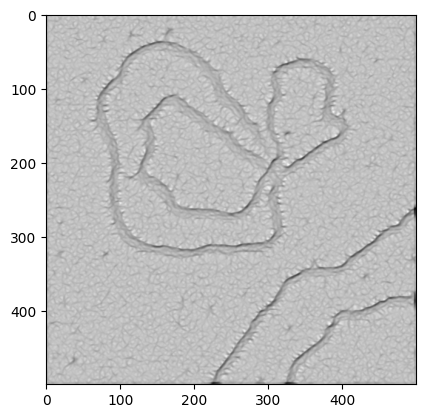

hessian_low_1s min max: -0.024123158072313824, 0.043938570609207875


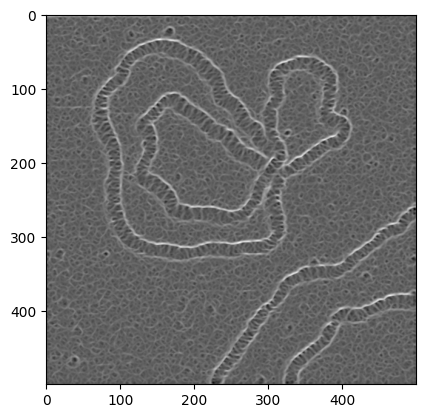

In [3]:
base_dir = Path("/Users/sylvi/topo_data/cats/training_data/cropped/")
assert base_dir.exists()

test_image_file = base_dir / "cropped_images" / "image_0.npy"
test_image = np.load(test_image_file)

# normalise the image
norm_lower_bound = 0
norm_upper_bound = 1

test_image = (test_image - np.min(test_image)) / (np.max(test_image) - np.min(test_image))

print(f"image min max: {np.min(test_image)}, {np.max(test_image)}")
plt.imshow(test_image, cmap="afmhot", vmin=norm_lower_bound, vmax=norm_upper_bound)
plt.show()

hessian_high_1s = apply_hessian_filter(test_image, hessian_component="high", sigma=1)
print(f"hessian_high_1s min max: {np.min(hessian_high_1s)}, {np.max(hessian_high_1s)}")
plt.imshow(hessian_high_1s, cmap="grey")
plt.show()
hessian_low_1s = apply_hessian_filter(test_image, hessian_component="low", sigma=1)
print(f"hessian_low_1s min max: {np.min(hessian_low_1s)}, {np.max(hessian_low_1s)}")
plt.imshow(hessian_low_1s, cmap="grey")
plt.show()
